In [1]:
from pyhdf.SD import SD, SDC
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
import re

In [ ]:

file_path = "/home/cluster/Projects/Flood_Forecasting/Dataset/MCDWD_L3.A2004213.h26v06.061.2025270185011.hdf"
hdf = SD(file_path, SDC.READ)

In [3]:


# List all datasets inside the file
print("Datasets:", list(hdf.datasets().keys()))

flood_layers = ['Flood_1Day_250m', 'Flood_2Day_250m', 'Flood_3Day_250m']

for layer_name in flood_layers:
    layer = hdf.select(layer_name)
    data = layer[:]
    print(f"\n{layer_name}")
    print(f"  Shape: {data.shape}")
    print(f"  Unique values: {np.unique(data)}")
    print(f"  Attributes: {layer.attributes()}")

# ── 1. Read with pyhdf ────────────────────────────────────────────────────────
data = hdf.select('Flood_1Day_250m')[:].astype(float)

hdf.end()

Datasets: ['FloodCS_1Day_250m', 'Flood_1Day_250m', 'Flood_2Day_250m', 'Flood_3Day_250m', 'TotalCounts_1Day_250m', 'TotalCounts_2Day_250m', 'TotalCounts_3Day_250m', 'ValidCountsCS_1Day_250m', 'ValidCounts_1Day_250m', 'ValidCounts_2Day_250m', 'ValidCounts_3Day_250m', 'WaterCountsCS_1Day_250m', 'WaterCounts_1Day_250m', 'WaterCounts_2Day_250m', 'WaterCounts_3Day_250m']

Flood_1Day_250m
  Shape: (4800, 4800)
  Unique values: [  0   1   2   3 255]
  Attributes: {'_FillValue': 255, 'valid_range': [0, 3], 'scale_factor': 1.0, 'add_offset': 0.0, 'long_name': 'Combined Terra and Aqua MODIS Flood_1Day_250m', 'units': 'none', 'description': '\n1 day flood pixels detected from Terra and Aqua\n  no clouds removed\n  terrain shadow pixels masked\n  HAND pixels masked\n  threshold from table, minimum of 1\nFlag values:\n    255 : Insufficient data\n    0 : No water\n    1 : Water (matches standard reference water)\n    2 : Recurring flood (expected seasonal flood)\n    3 : Flood (unusual)\n'}

Flood_2

In [ ]:

# ── 2. Mask fill value ────────────────────────────────────────────────────────
data[data == 255] = np.nan

# ── 3. Parse filename
fname = file_path.split('/')[-1]
parts = fname.split('.')

date_part = parts[1]             
year      = int(date_part[1:5])  
doy       = int(date_part[5:8])  

tile = parts[2]                 
h    = int(tile[1:3])            
v    = int(tile[4:6])         

print(f"Tile: {tile.upper()}  |  Year: {year}  |  DOY: {doy}")

Tile: H26V06  |  Year: 2004  |  DOY: 213


In [5]:

# ── 4. Compute lat/lon grid from MODIS sinusoidal tile formula ────────────────
R          = 6371007.181            # MODIS Earth radius (m)
tile_size  = np.radians(10.0) * R  # 10° tile in metres
pixel_size = tile_size / 4800      # 250 m nominal

# Upper-left sinusoidal corner (pixel centre)
x_ul = (h - 18) * tile_size + 0.5 * pixel_size
y_ul = (9  -  v) * tile_size - 0.5 * pixel_size

# 1-D coordinate arrays along each axis
x_sin = x_ul + np.arange(4800) * pixel_size   # (4800,)
y_sin = y_ul - np.arange(4800) * pixel_size   # (4800,)

# Convert sinusoidal → lat / lon
lat_1d = np.degrees(y_sin / R)                # (4800,)
lon_2d = np.degrees(                           # (4800, 4800)
    x_sin[np.newaxis, :] / (R * np.cos(np.radians(lat_1d[:, np.newaxis])))
)
lat_2d = np.tile(lat_1d[:, np.newaxis], (1, 4800))

# Mask pixels outside ±180 lon (sinusoidal edge artefacts)
data[np.abs(lon_2d) > 180] = np.nan

# ── 5. Downsample 4800×4800 → 480×480 for fast plotting ──────────────────────
step     = 10
data_ds  = data  [::step, ::step]
lat_ds   = lat_2d[::step, ::step]
lon_ds   = lon_2d[::step, ::step]

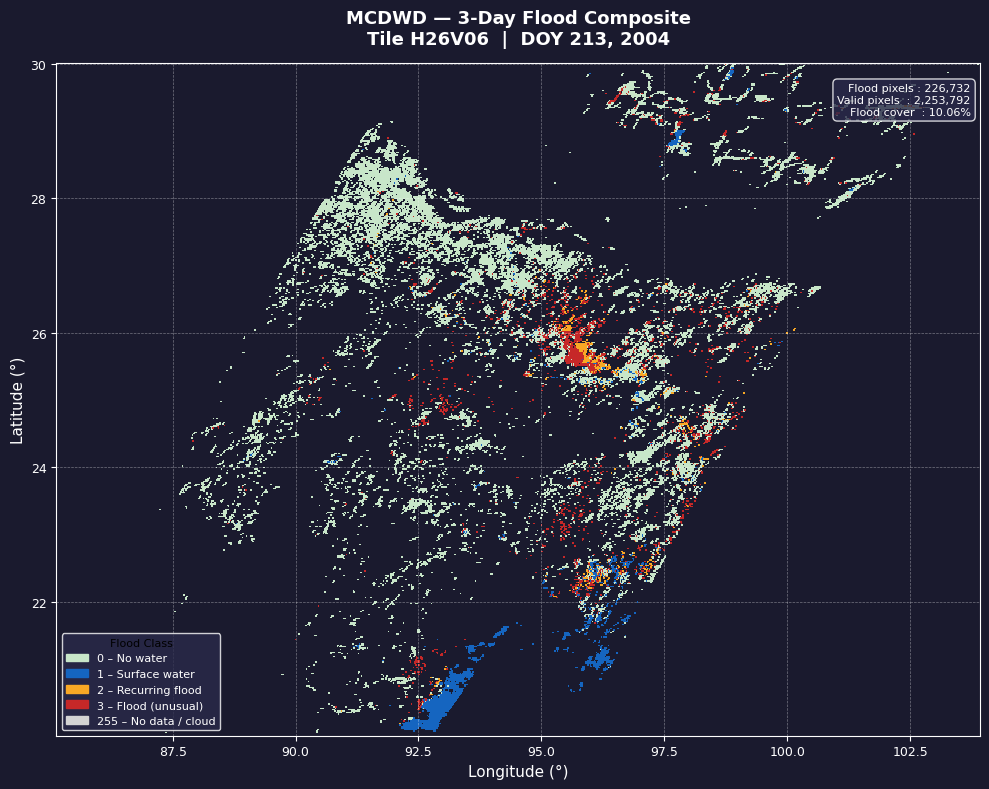

In [6]:

# ── 6. Discrete colormap ──────────────────────────────────────────────────────
colors = ['#c8e6c9', '#1565c0', '#f9a825', '#c62828']
cmap   = mcolors.ListedColormap(colors)
bounds = [-0.5, 0.5, 1.5, 2.5, 3.5]
norm   = mcolors.BoundaryNorm(bounds, cmap.N)

legend_patches = [
    mpatches.Patch(color='#c8e6c9', label='0 – No water'),
    mpatches.Patch(color='#1565c0', label='1 – Surface water'),
    mpatches.Patch(color='#f9a825', label='2 – Recurring flood'),
    mpatches.Patch(color='#c62828', label='3 – Flood (unusual)'),
    mpatches.Patch(color='lightgrey', label='255 – No data / cloud'),
]
# ── 7. Plot ───────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 8), facecolor='#1a1a2e')
ax.set_facecolor('#1a1a2e')

pcm = ax.pcolormesh(
    lon_ds, lat_ds, data_ds,
    cmap=cmap, norm=norm,
    shading='auto'
)

ax.grid(True, linestyle='--', linewidth=0.5, alpha=0.4, color='white')
ax.tick_params(colors='white', labelsize=9)
for spine in ax.spines.values():
    spine.set_edgecolor('white')

ax.set_xlabel('Longitude (°)', color='white', fontsize=11)
ax.set_ylabel('Latitude (°)',  color='white', fontsize=11)
ax.set_title(
    f'MCDWD — 3-Day Flood Composite\n'
    f'Tile {tile.upper()}  |  DOY {doy}, {year}',
    color='white', fontsize=13, fontweight='bold', pad=14
)

ax.legend(
    handles=legend_patches,
    loc='lower left', fontsize=8,
    facecolor='#2a2a4a', edgecolor='white',
    labelcolor='white',
    title='Flood Class', title_fontsize=8
)

# ── 8. Stats annotation ───────────────────────────────────────────────────────
total   = np.sum(~np.isnan(data))
flooded = np.sum(data == 3)
pct     = 100 * flooded / total if total > 0 else 0

ax.text(
    0.99, 0.97,
    f'Flood pixels : {flooded:,}\n'
    f'Valid pixels  : {total:,}\n'
    f'Flood cover  : {pct:.2f}%',
    transform=ax.transAxes, ha='right', va='top',
    color='white', fontsize=8,
    bbox=dict(facecolor='#2a2a4a', edgecolor='white', alpha=0.8, boxstyle='round,pad=0.4')
)

plt.tight_layout()

plt.show()